NOME:  Hercules André

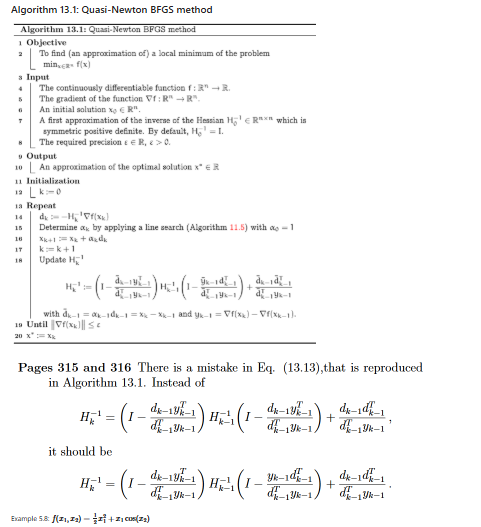

In [1]:
#Biblioteca
using LinearAlgebra
using Plots

# função
f(x) = 0.5 * x[1]^2 + x[1] * cos(x[2])

# Gradiente
function grad_f(x)
    g1 = x[1] + cos(x[2])
    g2 = -x[1] * sin(x[2])
    return [g1, g2]
end

grad_f (generic function with 1 method)

In [2]:
#Algoritmo de BFGS

function bfgs_solver(f, grad_f, x0; ϵ=1e-6, max_iter=100)
    # Inicialização (Linhas 11-12)
    k = 0
    x_k = Float64.(x0)
    n = length(x0)
    H_inv = Matrix{Float64}(I, n, n) 
    
    # Para fins de plotagem posterior
    history = [x_k]
    
    println("Iniciando iterações...")
    
    # Loop Repeat (Linha 13)
    while norm(grad_f(x_k)) > ϵ && k < max_iter
        g_k = grad_f(x_k)
        
        # 1. Direção de busca
        d_k = -H_inv * g_k
        
        # 2. Busca Linear (Backtracking) para encontrar αk 
        α = 1.0
        c1 = 1e-4 # Parâmetro de Armijo
        while f(x_k + α * d_k) > f(x_k) + c1 * α * dot(g_k, d_k)
            α *= 0.5
        end
        
        # 3. Atualização da solução 
        x_next = x_k + α * d_k
        
        # 4. Preparação para o Update da Hessiana 
        s_k = x_next - x_k      
        y_k = grad_f(x_next) - g_k
        
        # Cálculo dos termos da fórmula BFGS
        # ρ = 1 / (y_k' * s_k) facilita a conta
        if dot(y_k, s_k) > 1e-10 # Evita divisão por zero
            ρ_k = 1.0 / dot(y_k, s_k)
            Termo1 = (I - ρ_k * s_k * y_k')
            Termo2 = (I - ρ_k * y_k * s_k')
            
            # Update H_k^-1 
            H_inv = Termo1 * H_inv * Termo2 + ρ_k * s_k * s_k'
        end
        
        x_k = x_next
        k += 1
        push!(history, x_k)
    end
    
    println("Concluído em $k iterações.")
    return x_k, history
end

bfgs_solver (generic function with 1 method)

In [3]:
# ponto inicial 
x0_input = [1.0, 1.0]

2-element Vector{Float64}:
 1.0
 1.0

In [4]:
#Executar

x_opt, path = bfgs_solver(f, grad_f, x0_input)
println("Mínimo encontrado: ", x_opt)

Iniciando iterações...
Concluído em 16 iterações.
Mínimo encontrado: [-1.0000006286691057, -2.651603031688697e-7]


In [5]:
#Grafico
x1_range = range(-2.5, 2.5, length=100)
x2_range = range(-1.0, 4.0, length=100)
z = [f([x1, x2]) for x2 in x2_range, x1 in x1_range]


100×100 Matrix{Float64}:
 1.77424   1.67654   1.5814    1.4888    …  4.17376   4.32348   4.47576
 1.66977   1.57418   1.48114   1.39065      4.27401   4.42585   4.58023
 1.569     1.47544   1.38444   1.29599      4.37071   4.52458   4.681
 1.4722    1.3806    1.29155   1.20506      4.4636    4.61942   4.7778
 1.37961   1.28989   1.20271   1.11809      4.55244   4.71014   4.87039
 1.29148   1.20353   1.11814   1.03529   …  4.63701   4.79649   4.95852
 1.20802   1.12176   1.03805   0.956894     4.7171    4.87826   5.04198
 1.12945   1.04478   0.962658  0.883087     4.79249   4.95524   5.12055
 1.05597   0.972786  0.892148  0.81406      4.863     5.02724   5.19403
 0.987771  0.90596   0.8267    0.749991     4.92845   5.09407   5.26223
 0.925018  0.844475  0.766483  0.691041  …  4.98867   5.15555   5.32498
 0.867876  0.788487  0.711649  0.637362     5.0435    5.21154   5.38212
 0.81649   0.738139  0.662339  0.58909      5.09281   5.26189   5.43351
 ⋮                                       ⋱

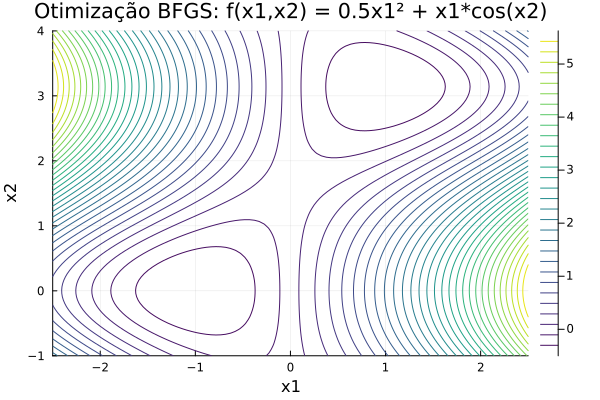

In [6]:
#Plot o Contorno
p = contour(x1_range, x2_range, z, levels=30, color=:viridis, 
            title="Otimização BFGS: f(x1,x2) = 0.5x1² + x1*cos(x2)",
            xlabel="x1", ylabel="x2")

In [7]:
#coordenadas do histórico para plotar o caminho
px = [p[1] for p in path]
py = [p[2] for p in path]

17-element Vector{Float64}:
  1.0
  1.8414709848078965
  1.5052776232086946
  1.4806158114630743
  1.424776432096398
  1.335276146911984
  1.1933200622948827
  0.975538397458751
  0.6686436607614716
  0.31758456217128206
 -0.14304814932631804
  0.030863641904423034
  0.0007934061175317517
 -0.000974483694799193
 -0.0003116919285557797
 -1.1026099659112315e-5
 -2.651603031688697e-7

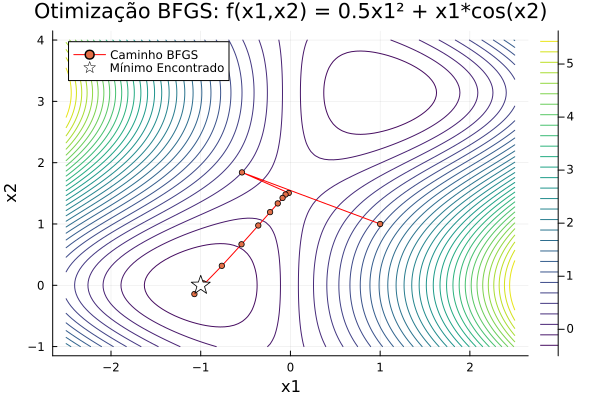

In [8]:
# Plotar o caminho e o ponto final
plot!(px, py, marker=:circle, linecolor=:red, label="Caminho BFGS", markersize=3)
scatter!([x_opt[1]], [x_opt[2]], color=:white, markershape=:star, 
         markersize=10, label="Mínimo Encontrado")

-------------------------------------------------------------------------------------------------------

In [10]:
#Bibliotecas
using LinearAlgebra
using Plots

# Função 
f(x) = 0.5 * x[1]^2 + x[1] * cos(x[2])
grad_f(x) = [x[1] + cos(x[2]), -x[1] * sin(x[2])]

grad_f (generic function with 1 method)

In [11]:
#Função de Rosenbrock

f_rosen(x) = (1.0 - x[1])^2 + 100.0 * (x[2] - x[1]^2)^2
function grad_rosen(x)
    g1 = -2.0 * (1.0 - x[1]) - 400.0 * x[1] * (x[2] - x[1]^2)
    g2 = 200.0 * (x[2] - x[1]^2)
    return [g1, g2]
end


grad_rosen (generic function with 1 method)

In [22]:
#Algoritmo BFGS

function bfgs_algorithm(f, grad_f, x0; ϵ=1e-6, max_iter=500)
    
    # Inicialização 
    k = 0
    x_k = Float64.(x0)
    n = length(x0)
    H_inv = Matrix{Float64}(I, n, n) # H0^-1 = I por padrão 
    
    history = [x_k]
    
    # Repeat 
    while norm(grad_f(x_k)) > ϵ && k < max_iter
        g_k = grad_f(x_k)
        
        # Direção de busca 
        d_k = -H_inv * g_k
        
        # Line Search simples para determinar αk 
        α = 1.0
        while f(x_k + α * d_k) > f(x_k) + 1e-4 * α * dot(g_k, d_k)
            α *= 0.5
        end
        
        # Atualização x_{k+1} 
        x_next = x_k + α * d_k
        
        # Preparação para o Update de H_k^-1 
        s_k = x_next - x_k  # d_barra na imagem
        y_k = grad_f(x_next) - g_k
        
        # Fórmula de Atualização BFGS
        ρ_k = 1.0 / (y_k' * s_k)
        term1 = (I - ρ_k * s_k * y_k')
        term2 = (I - ρ_k * y_k * s_k')
        H_inv = term1 * H_inv * term2 + ρ_k * (s_k * s_k')
        
        x_k = x_next
        k += 1
        push!(history, x_k)
    end
    
    return x_k, history
end

bfgs_algorithm (generic function with 1 method)

In [16]:
# Execução para Rosenbrock
x0_rosen = [-1.2, 1.0]

2-element Vector{Float64}:
 -1.2
  1.0

In [23]:
#Executar 
x_opt, path = bfgs_algorithm(f_rosen, grad_rosen, x0_rosen)

([0.999999995227867, 0.9999999902393274], [[-1.2, 1.0], [-0.9894531249999999, 1.0859375], [-0.7723458059823377, 0.570592398338829], [-0.7412854699429574, 0.518425870728817], [-0.46315775756543887, 0.14171129541314764], [-0.49759058772117737, 0.26729175378644376], [-0.3819711131899329, 0.13390898661843903], [-0.3047508985165938, 0.0582936269482079], [-0.26165859904065375, 0.036136852447949466], [-0.1233498957312184, 0.0013522025360350881]  …  [0.8863996568508534, 0.781153449313648], [0.923075765873759, 0.8514410533382473], [0.9651698968346757, 0.9254380986042805], [0.9653036510179496, 0.9311253033049054], [0.9839789961048138, 0.9678642141734655], [0.9978959437896165, 0.995346840978825], [0.9992944949932825, 0.9986128993449341], [1.0000120913104305, 1.0000214992405543], [0.9999996551552799, 0.9999992842941727], [0.999999995227867, 0.9999999902393274]])

In [24]:
#Gráfico
x_range = range(-2.0, 2.0, length=100)
y_range = range(-0.5, 3.0, length=100)
z = [log10(f_rosen([x, y]) + 1) for y in y_range, x in x_range]

100×100 Matrix{Float64}:
 3.30856  3.27723  3.24539  3.21305  …  3.21105  3.2435   3.27543  3.30685
 3.30175  3.27016  3.23806  3.20544     3.2034   3.23613  3.26833  3.30001
 3.29488  3.26303  3.23067  3.19777     3.19569  3.2287   3.26117  3.29311
 3.28795  3.25585  3.22321  3.19002     3.18791  3.22121  3.25396  3.28616
 3.28097  3.24861  3.21569  3.18221     3.18006  3.21366  3.24668  3.27915
 3.27393  3.2413   3.20811  3.17432  …  3.17213  3.20604  3.23935  3.27208
 3.26684  3.23394  3.20045  3.16637     3.16414  3.19835  3.23195  3.26496
 3.25969  3.22651  3.19273  3.15834     3.15607  3.19059  3.22448  3.25777
 3.25248  3.21902  3.18494  3.15023     3.14792  3.18276  3.21696  3.25053
 3.24521  3.21146  3.17708  3.14205     3.1397   3.17486  3.20936  3.24323
 3.23787  3.20384  3.16915  3.1338   …  3.13139  3.16689  3.2017   3.23586
 3.23048  3.19615  3.16115  3.12546     3.12301  3.15884  3.19398  3.22843
 3.22302  3.18839  3.15307  3.11705     3.11455  3.15072  3.18618  3.22094


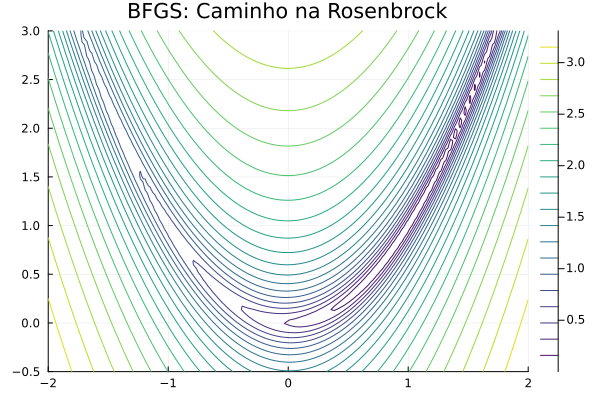

In [25]:
#Plot o Contorno
contour(x_range, y_range, z, levels=20, color=:viridis, title="BFGS: Caminho na Rosenbrock")

In [26]:
#coordenadas do histórico para plotar o caminho
px = [p[1] for p in path]
py = [p[2] for p in path]

35-element Vector{Float64}:
  1.0
  1.0859375
  0.570592398338829
  0.518425870728817
  0.14171129541314764
  0.26729175378644376
  0.13390898661843903
  0.0582936269482079
  0.036136852447949466
  0.0013522025360350881
 -0.031125935086617262
 -0.015499334788412089
  0.058396378437726285
  ⋮
  0.5726515821907221
  0.6986633934377191
  0.781153449313648
  0.8514410533382473
  0.9254380986042805
  0.9311253033049054
  0.9678642141734655
  0.995346840978825
  0.9986128993449341
  1.0000214992405543
  0.9999992842941727
  0.9999999902393274

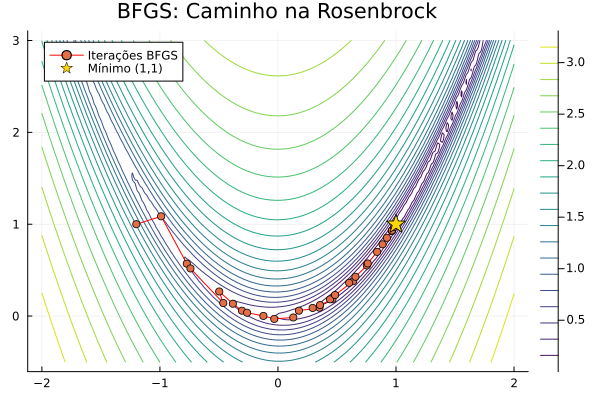

In [27]:
#Gráfico Final
plot!(px, py, marker=:circle, linecolor=:red, label="Iterações BFGS")
scatter!([1.0], [1.0], color=:gold, markershape=:star, markersize=10, label="Mínimo (1,1)")